**Author:** Christopher Millward<br>
**Date:** June 19, 2026

The R matrices built from the data were failing my orthonormality tests. The purpose of this notebook is to audit the orthonormality of the dataset.

---

I'm going to perform the following audits:
1. Calculate how far away from orthonormality each R matrix is in each data file. 
2. Visualize the distributions of these variances
3. Plot the variances on a time series to assess stability / drift.

In [1]:
# set root folder to project root
import os 
import sys

root_path = os.path.abspath(os.path.join(".."))
if root_path not in sys.path:
    sys.path.insert(0, root_path)

In [ ]:
# Import the data
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
from utils.data_loading import load_participant_details
from utils.kinematics.general_helpers import create_rotation_matrices
import time

participant_details = load_participant_details('../raw_data/participant_details.xlsx')

In [ ]:
# Helper functions
def calculate_and_save_variances(data, rtsa_side, fpath):
    """Helper function to calculate and save variances for a single arm"""

    # build matrices
    matrices = create_rotation_matrices(data, rtsa_side)

    # calculate variance from orthonormality
    I = np.eye(3)
    ortho_variance_arrays = (np.transpose(matrices, axes=(0, 2, 1)) @ matrices - I)
    variances = np.linalg.norm(ortho_variance_arrays, axis=(1, 2))

    # save variances
    variance_data.extend(
        {
            "participant": fpath,
            "variance": v,
        }
        for v in variances
    )

def get_rtsa_sides(p_details):
    """
    Helper function to properly format the RTSA sides for a participant 
    (will properly fix this in a separate commit). Returning in a list 
    just in case someone is bilateral.
    """
    match p_details['rtsa_side']:
        case "right":
            return ["R"]
        case "left":
            return ["L"]
        case "both":
            return ["R", "L"]
        case None:
            return None


# Analysis
start_time = time.perf_counter()
variance_data = []
for participant in participant_details:
    # get data
    fpath = participant['filename']
    data = np.loadtxt(
        f'../raw_data/{fpath}', delimiter='\t', skiprows=1, usecols=range(1, 19))

    # Run analysis
    sides = get_rtsa_sides(participant)
    if sides is not None:
        for side in sides:
            calculate_and_save_variances(data, side, fpath)

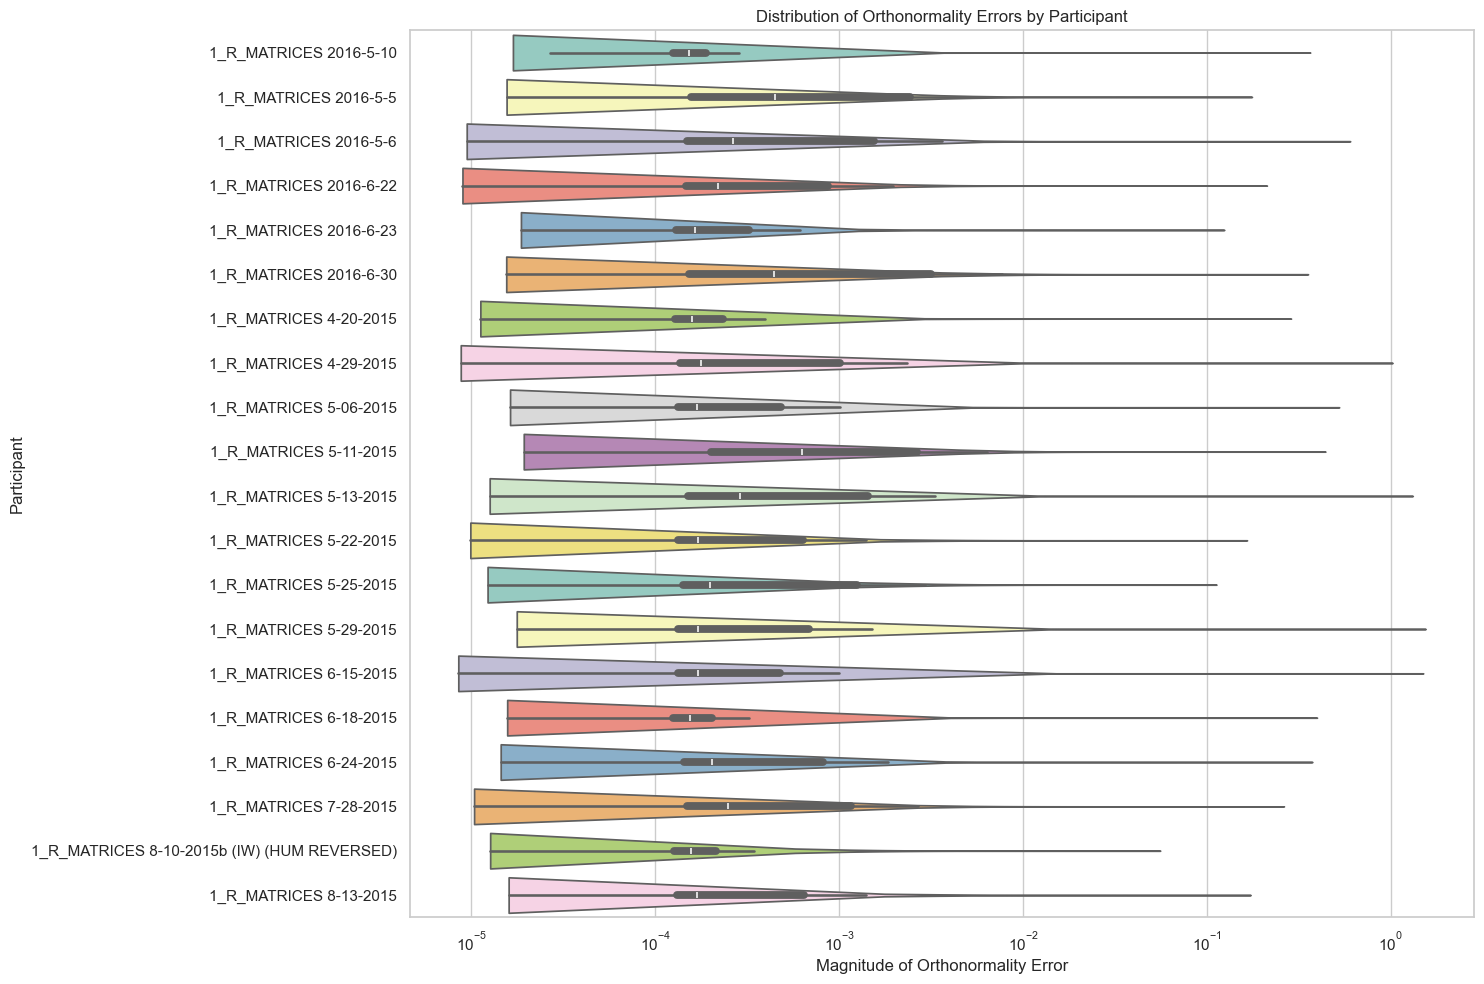

In [4]:
# Plot distributions
sns.set_theme(style="whitegrid", context="notebook")
plot_data = pd.DataFrame(variance_data)

plt.figure(figsize=(15, 10))

sns.violinplot(
    data=plot_data,
    y="participant",
    x="variance",
    cut=0,
    palette="Set3",
    hue="participant",
    legend=False,
)

plt.xscale("log")
plt.title("Distribution of Orthonormality Errors by Participant")
plt.xlabel("Magnitude of Orthonormality Error")
plt.ylabel("Participant")
plt.tight_layout()
plt.show()

In [5]:
print("=== Participant-Level Variance Descriptions ===")
print(plot_data.groupby("participant")["variance"].describe().to_markdown())

print("\n\n=== Overall Variance Description ===")
all_descr = plot_data.groupby("participant")["variance"].describe()['mean'].describe()
print(all_descr.to_markdown())

=== Participant-Level Variance Descriptions ===
| participant                                 |   count |        mean |        std |         min |         25% |         50% |         75% |       max |
|:--------------------------------------------|--------:|------------:|-----------:|------------:|------------:|------------:|------------:|----------:|
| 1_R_MATRICES 2016-5-10                      |  404800 | 0.000450288 | 0.00242713 | 1.68493e-05 | 0.000124327 | 0.000152516 | 0.000189367 | 0.364534  |
| 1_R_MATRICES 2016-5-5                       |  404913 | 0.00235723  | 0.00492682 | 1.55641e-05 | 0.000156083 | 0.000448457 | 0.00241732  | 0.175938  |
| 1_R_MATRICES 2016-5-6                       |  365000 | 0.00170722  | 0.00522165 | 9.44695e-06 | 0.000149084 | 0.000266199 | 0.00154711  | 0.601645  |
| 1_R_MATRICES 2016-6-22                      |  233732 | 0.00107116  | 0.00289256 | 8.95834e-06 | 0.000146826 | 0.00021973  | 0.00087033  | 0.212051  |
| 1_R_MATRICES 2016-6-23          

Overall, most of the data is around the 1e-3 (closer to the side of 1e-4) magnitude away from perfectly orthonormal. After some digging, it turns out that this can be on the upper bound of expected variance in IMUs. Plugging away at some math (and digging into the internet), this means each frame is 0.02° - 0.1° away from being a valid rotation. It may be the case that this is caused by some sensor fusion noise or conversion noise (+ occasional soft-tissue artifact).

NOTE: This is **not** to be confused with orientation error. This orthonormality test is just telling us a) if the axes are all perpendicular, and if the axes lengths are all of unit length.

By stating our orthonormality is off by 1e-3, we are saying "the axes are _slightly_ not perpendicular and/or our axes are _sightly_ not of unit length", but the dominant orientation component may still be correct. As in, our motion signal may still be preserved, we just lost _a bit_ of rigid-body constraint. BUT this assumes the magnitude of orthonormal variance is stable. We seem to have quite a bit of variance through the data. I just want to plot it on a time-series to see if there is any drift we can control for in this signal.

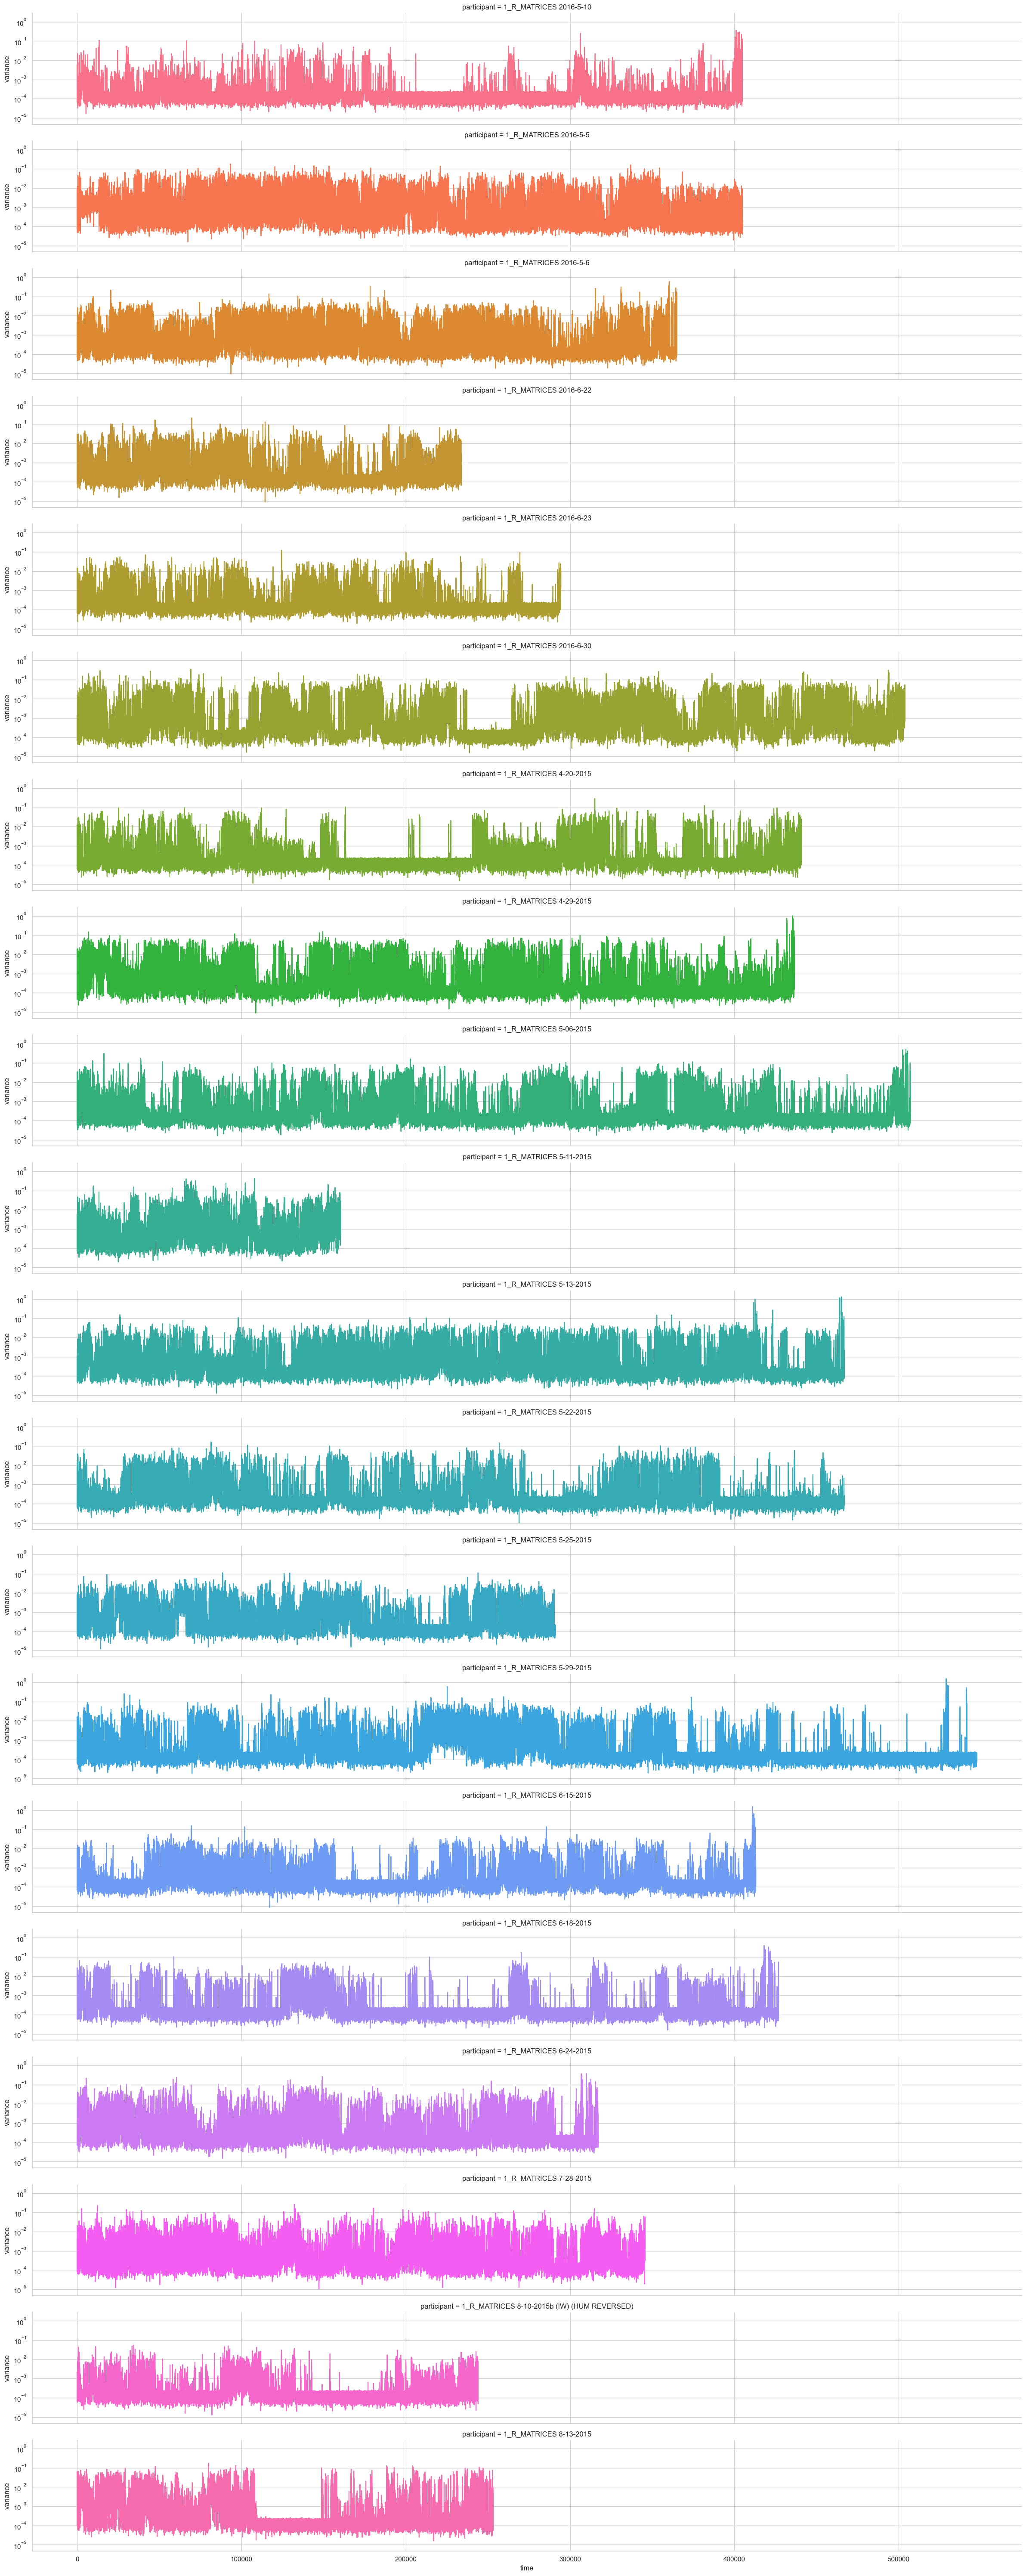

In [6]:
# Create a common x-axis for all participants
plot_data["time"] = plot_data.groupby("participant").cumcount()

# Plot the orthonormality errors on a time-series
sns.set_theme(style="whitegrid", context="notebook")

sns.relplot(
    data=plot_data,
    x="time",
    y="variance",
    col="participant",  # creates a new subplot column for each participant
    col_wrap=1,  # adjusts how many subplots appear per row
    kind="line",
    facet_kws=dict(
        sharey=True, 
        sharex=True
    ),
    height=3,  # height of each individual subplot
    aspect=8,  # width-to-height ratio of each subplot
    hue="participant",
    legend = False
)

plt.yscale("log")
plt.tight_layout()
plt.show()

Ok, this looks much worse than I expected... If it was a physical axis alignment or thermal issue, we would see a constant or at least trending error. These values seem to be quite rapid and dynamic. Also, the magnitudes span 3 orders, which is quite large for any heat or alignment-related error. From this, I think we can rule out any physical hardware-related issues.

My current best guesses for sources of error are:
- Sensor fusion algorithm is spitting out poor estimates (in which case we will have to abandon the data completely).
- Algorithmic errors in the pipeline from quats --> R matrices --> relative R matrices (in which case we can correct and use the data). Possibly from:
    - failure to normalize quaternions before conversion to R matrix
    - errors in smoothing / resampling
    - time synchronization errors in calculating relative R matrices

I don't believe the current state of the data is reliable enough for us to ethically base any analysis on. We must fix this issue before continuing.